# 01 Solar fluxes and spectra
Загрузка потоков, график и toy B8 spectrum.

In [1]:
from pathlib import Path
import os, sys
PROJECT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT / "outputs" / "mplconfig"))
(PROJECT / "outputs").mkdir(exist_ok=True)
(PROJECT / "outputs" / "mplconfig").mkdir(exist_ok=True)
sys.path.insert(0, str(PROJECT / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from solar_neutrino.fluxes import load_flux_table, plot_fluxes
from solar_neutrino.spectra import load_b8_spectrum, normalize_spectrum, interpolate_spectrum, toy_b8_spectrum
from solar_neutrino.plotting import plot_spectrum

## Load flux table

In [2]:
fluxes = load_flux_table(PROJECT / "data" / "solar_fluxes_reference.csv")
fluxes

,source,flux_cm2_s,kind,comment
0,pp,5.980000e+10,continuum,pp-chain dominant flux
1,pep,1.440000e+08,line,monoenergetic
2,hep,7.980000e+03,continuum,rare high-energy tail
3,Be7,4.930000e+09,line,electron capture lines
4,B8,5.460000e+06,continuum,important for water Cherenkov detectors
5,N13,2.780000e+08,continuum,CNO
6,O15,2.050000e+08,continuum,CNO
7,F17,5.290000e+06,continuum,CNO


## Plot fluxes

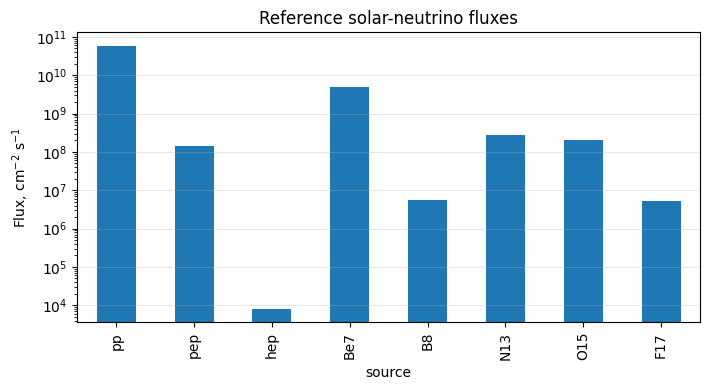

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
plot_fluxes(fluxes, ax=ax)
fig.tight_layout()
fig.savefig(PROJECT / "outputs" / "solar_fluxes_notebook.png", dpi=160)
plt.show()

## B8 spectrum normalization

In [4]:
path = PROJECT / "data" / "b8_spectrum.csv"
if path.exists():
    E, shape = load_b8_spectrum(path)
else:
    E = np.linspace(0.05, 16.0, 320); shape = toy_b8_spectrum(E)
shape = normalize_spectrum(E, shape)
b8_spectrum = interpolate_spectrum(E, shape)
np.trapezoid(shape, E)

np.float64(1.0)

## Plot B8 spectrum

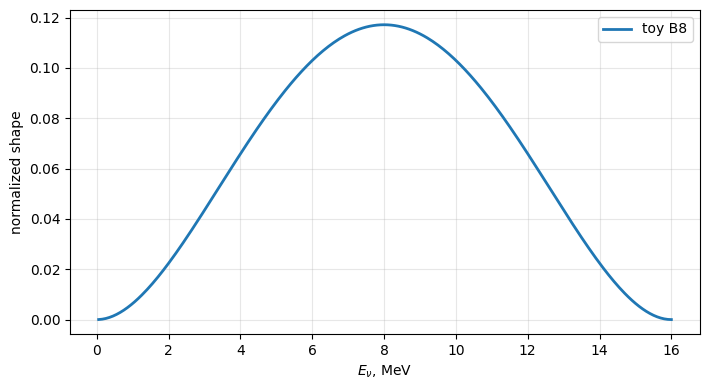

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
plot_spectrum(E, shape, ax=ax, label="toy B8")
fig.tight_layout()
fig.savefig(PROJECT / "outputs" / "b8_spectrum_notebook.png", dpi=160)
plt.show()

## Save intermediate data

In [6]:
pd.DataFrame({"E_MeV": E, "shape_normalized": shape}).to_csv(PROJECT / "outputs" / "b8_spectrum_normalized.csv", index=False)